# Basic Receiver Processing

In this notebook, we will explore the basic processing steps involved in a receiver system, including:
* matched filter
* down-sampling
* symbol decision

We will do this over a simulated AWGN channel to understand the impact of noise on the receiver performance. Critical functions for a practical receiver, including synchronization in time, frequency, and phase will be developed in the following weeks. This week's goal is to demonstrate that our basic receiver achieves the theoretical error rate performance.

In [1]:
import numpy as np
import sounddevice as sd

# Matplotlib is a plotting library for creating static, animated, and interactive visualizations in Python. The 'inline' magic command allows the plots to be displayed directly in the notebook.
import matplotlib.pyplot as plt
%matplotlib inline

# tweak the appearance of the plots
plt.rcParams['figure.figsize'] = (10, 6)  # Set the default figure size for plots

# seaborn is a statistical data visualization library based on Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.
import seaborn as sns
# Set the context for Seaborn plots to 'talk', which is suitable for presentations and larger text sizes.
sns_context = 'talk' 
sns.set_theme(context=sns_context, style="ticks", palette="deep")

In [2]:
from dc_632_26.sources import RandomBitSource
from dc_632_26.constellations import standard_constellation
from dc_632_26.modulation import modulation
from dc_632_26.pulses import CosineSquaredPulse
from dc_632_26.pulse_shaper import PulseShaper
from dc_632_26.freq_shift import Upconverter

from dc_632_26.transmitter import Transmitter

In [3]:
from scipy import special

def Q(x):
    """Gaussian error integral"""
    return 0.5 - 0.5*special.erf(x/np.sqrt(2))

## Transmitted Signal

Synthesize a transmitted signal using the transmitter object `tx` and a random bit source.

In [20]:
# Configure transmitter parameters
fc = 10e3
fs = 44e3
fsT = 64

constellation = standard_constellation.QPSK
pulse = CosineSquaredPulse(fsT)
pulse_shaper = PulseShaper(pulse, fsT)
uc = Upconverter(fc, fs, gain=np.sqrt(2.)) # gain = sqrt(2) to maintain Eb and Es

tx = Transmitter(fc, fs, constellation, pulse_shaper, uc)

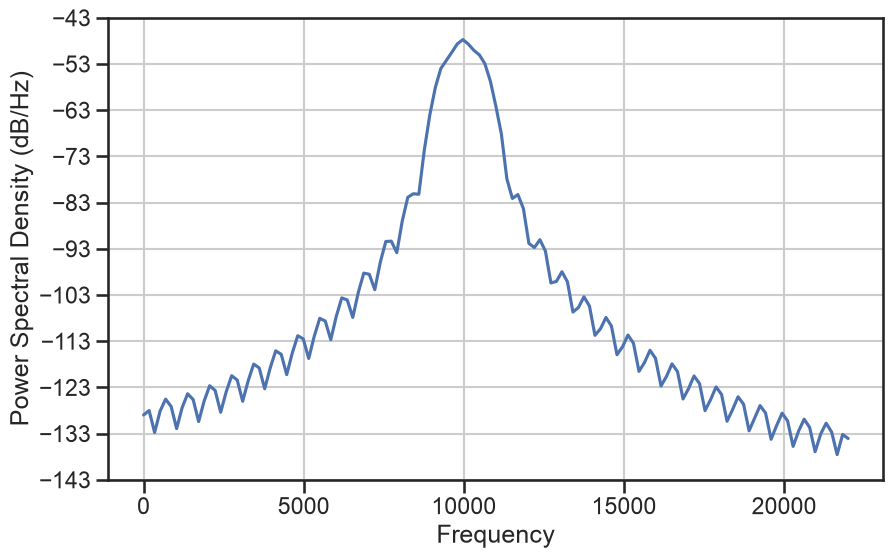

Constellation E_s:  1.0
measured E_s:  0.9999999997033737
Aproximate BW:  687.5 Hz


In [21]:
# make a passband signal from random bits
N_bits = 1000
src = RandomBitSource()
bits = src.get_bits(N_bits)
tx_sig = tx.modulate(bits)

# check the PSD
plt.psd(tx_sig, Fs=fs)
plt.show()

# check the energy per symbol
print("Constellation E_s: ", constellation.Es)
print("measured E_s: ", np.sum(np.abs(tx_sig)**2)/(N_bits/constellation.bps))
print("Aproximate BW: ", fs/fsT, "Hz")

## Simulate an AWGN channel

We want to add noise to the transmitted signal to simulate an AWGN channel. Our goal is to set the noise variance such that the signal-to-noise ratio (Specifically, $E_b/N_0$) matches a desired value, say 10~dB.

Since pulses are normalized to have unit energy, the energy per symbol $E_s$ and per bit $E_b$ is set by the constellation, i.e., $E_s = \text{constellation.Es}$ and $E_b = E_s / \text{constellation.bps}$.

For a desired $E_b/N_0$ value, the noise variance $\sigma^2$ can be calculated as:
$$
\sigma^2 = \frac{E_b}{10^{E_b/N_0 \text{(dB)}/10}}
$$

For a passband signal, this is the variance of the real-valued noise. For complex baseband signals, the noise variance is split equally between the real and imaginary parts, i.e., each has variance $\sigma^2/2$.

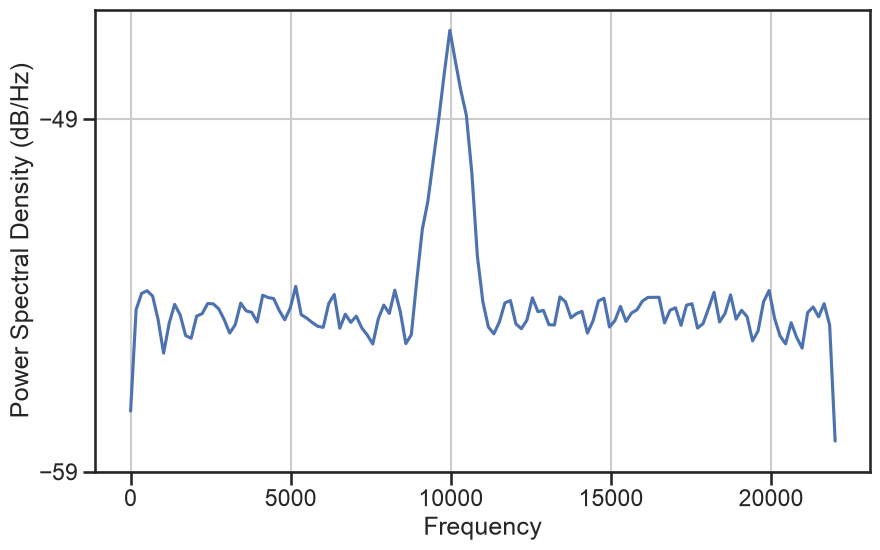

In [22]:
EbN0_dB = 8  # Desired Eb/N0 in dB
EbN0 = 10**(EbN0_dB/10)  # Convert Eb/N0 from dB to linear scale
Eb = constellation.Eb  # Energy per bit
sigma2 = Eb / EbN0  # Noise variance 

if uc is None:
    # digital baseband AWGN noise addition
    rx_sig = tx_sig + np.sqrt(sigma2/2) * (np.random.randn(*tx_sig.shape) + 
                                           1j*np.random.randn(*tx_sig.shape))
else:
    # passband AWGN noise addition
    rx_sig = tx_sig + np.sqrt(sigma2) * np.random.randn(*tx_sig.shape)

plt.psd(rx_sig, Fs=fs)
plt.show()

## Receiver Processing

The receiver performs down-conversion,matched filtering, sampling, and symbol detection to recover the transmitted bits from the noisy received signal.

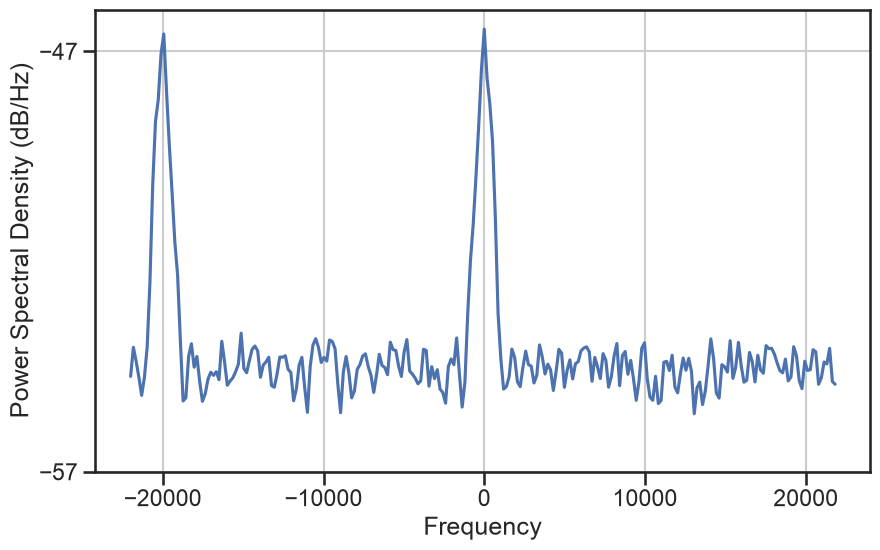

In [23]:
## down-convert; without filtering, use matched filter for that
if uc is not None:
    rx_bb = rx_sig * np.sqrt(2)*np.exp(-1j*2*np.pi*fc*np.arange(len(rx_sig))/fs)
else:
    rx_bb = rx_sig

plt.psd(rx_bb, Fs=fs)
plt.show()

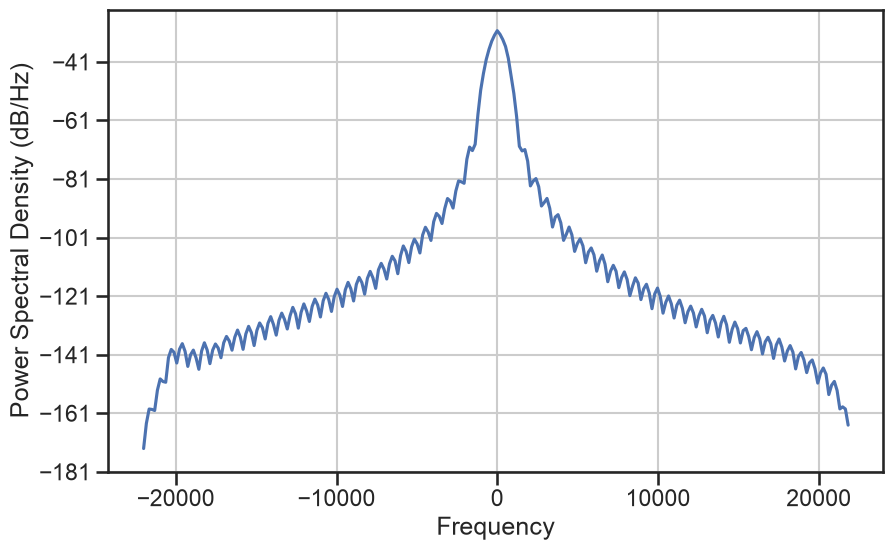

In [24]:
## matched filtering
rx_mf = np.convolve(rx_bb, np.conj(pulse.samples[::-1]))

plt.psd(rx_mf, Fs=fs)
plt.show()

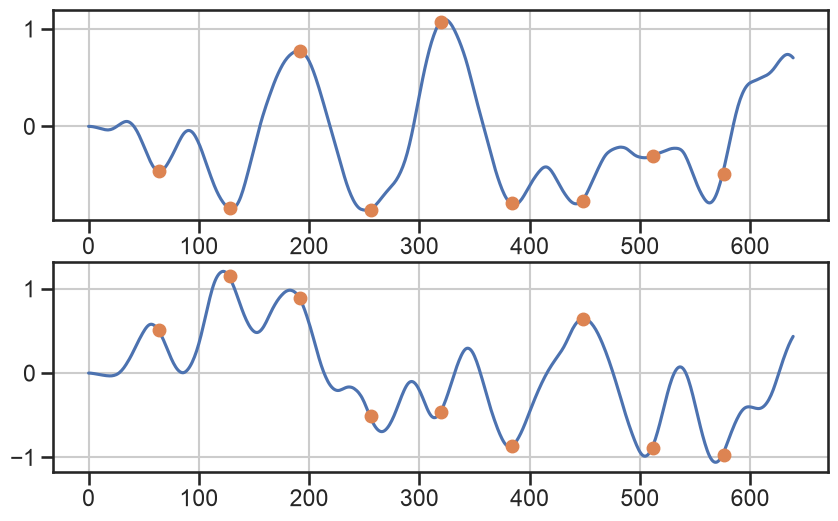

In [25]:
# time-domain plot show I and Q:
plt.subplot(2,1,1)
plt.plot(np.real(rx_mf)[:10*fsT])
plt.plot(fsT*np.arange(1,10), np.real(rx_mf)[fsT-1:10*fsT-1:fsT], 'o')
plt.grid()
plt.subplot(2,1,2)
plt.plot(np.imag(rx_mf)[:10*fsT])
plt.plot(fsT*np.arange(1,10), np.imag(rx_mf)[fsT-1:10*fsT-1:fsT], 'o')
plt.grid()
plt.show()

In [26]:
# slicer
# this slicer only works for this specific QPSK constellation
rx_symbols = rx_mf[fsT-1::fsT]  # for this pulse shape, these are the best sample instances
#rx_bits = constellation.demodulate(rx_symbols)

rx_bits = np.zeros(N_bits, dtype=int)
for n in range(N_bits//2):
    rx_bits[2*n] = int(np.imag(rx_symbols[n]) < 0)
    rx_bits[2*n+1] = int(np.real(rx_symbols[n]) < 0)

print(f"bit errors: {np.sum(bits != rx_bits)} out of {N_bits}")
print(f"Expected bit errors: {Q(np.sqrt(2*10**(EbN0_dB/10))) * N_bits}")

bit errors: 8 out of 1000
Expected bit errors: 0.1909077740759879


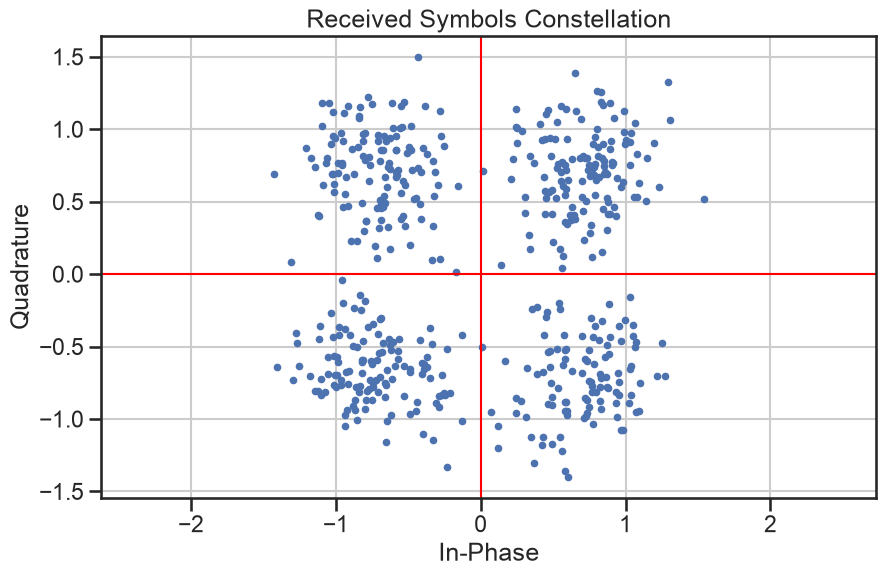

In [27]:
plt.plot(np.real(rx_symbols), np.imag(rx_symbols), '.')
plt.xlabel('In-Phase')
plt.ylabel('Quadrature')
plt.title('Received Symbols Constellation')
plt.grid(True)
plt.axis('equal')
plt.axhline(0, color='red', linewidth=1.5)
plt.axvline(0, color='red', linewidth=1.5)    
plt.show()

## Monte Carlo Simulation

Repeatedly simulate transmission and reception to estimate the bit error rate (BER) under the given channel conditions. Simulate until approximately 400 bit errors have been observed or a maximum number of iterations is reached.

In [29]:
# Configurations
EbN0_dB = 7  # Example value for Eb/N0 in dB
EbN0 = 10**(EbN0_dB/10)  # Convert Eb/N0 from dB to linear scale
sigma2 = constellation.Eb/(EbN0)  # Noise variance for AWGN channel

# disable up-conversion; the Upconverter has memory and the phase continuity messes up the simulation results
uc = tx.uc = None

n_error = 0
max_bits = 1e6  # Maximum number of bits to simulate
target_errors = 400  # Target number of bit errors to observe

n_bits = 0  # Counter for the number of bits simulated

while n_error < target_errors and n_bits < max_bits:
    # transmitter = 
    bits = src.get_bits(N_bits)
    n_bits += N_bits
    tx_sig = tx.modulate(bits)

    # channel
    if uc is None:
        rx_sig = tx_sig + np.sqrt(sigma2/2) * (np.random.randn(*tx_sig.shape) + 
                                               1j*np.random.randn(*tx_sig.shape))
    else:
        rx_sig = tx_sig + np.sqrt(sigma2) * np.random.randn(*tx_sig.shape)

    # receiver
    if uc is not None:
        rx_bb = rx_sig * np.sqrt(2)*np.exp(-1j*2*np.pi*fc*np.arange(len(rx_sig))/fs)
    else:
        rx_bb = rx_sig

    rx_mf = np.convolve(rx_bb, np.conj(pulse.samples[::-1]))
    rx_symbols = rx_mf[fsT-1::fsT]  # for this pulse shape, these are the best sample instances

    rx_bits = np.zeros(N_bits, dtype=int)
    for n in range(N_bits//2):
        rx_bits[2*n] = int(np.imag(rx_symbols[n]) < 0)
        rx_bits[2*n+1] = int(np.real(rx_symbols[n]) < 0)
    
    # count errors
    n_error += np.sum(bits != rx_bits)

print(f"Simulated {n_bits} bits, observed {n_error} errors, estimated BER = {n_error/n_bits}")
print(f"Expected BER = {Q(np.sqrt(2*EbN0))} at Eb/N0 = {EbN0_dB} dB")

Simulated 537000 bits, observed 402 errors, estimated BER = 0.0007486033519553073
Expected BER = 0.0007726748153784602 at Eb/N0 = 7 dB


## To dos:
- Implement a down-converter block, possibly with some down-sampling (e.g., from 64x to 8x)
  * should that be phase-continuous? Or, should that be stripped from the up-converter?
- Implement a generic slicer that works for any constellation; this is the counter-part of the modulator
- Implement a matched filter and down-sampler:
  * those should be separate as we will insert functionality between the two
  * for the simulated case, where does the matched filter output get sampled for best performance
  * how do we figure out the best sampling time in practice?
- how big are the (95%) confidence intervals for the BER when we simulate to 400 errors?
- Provide expressions for the (approximate) BER for each constellation (given an $E_b/N_0$)
